<a href="https://colab.research.google.com/github/belisekanziga/AIMS-Workspace-Generator/blob/main/amaliteck_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The "Last Mile" Logistics Auditor

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

orders = pd.read_csv("olist_orders_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")
customers = pd.read_csv("olist_customers_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
translation = pd.read_csv("product_category_name_translation.csv")

# Build MASTER DATASET (Story 1)

In [4]:
df = orders.merge(reviews, on="order_id", how="left")
df = df.merge(customers, on="customer_id", how="left")
df = df.merge(order_items, on="order_id", how="left")
df = df.merge(products, on="product_id", how="left")
df = df.merge(translation, on="product_category_name", how="left")

# Check duplicates

In [5]:

print("Shape:", df.shape)
print("Duplicates:", df.duplicated().sum())

Shape: (114092, 33)
Duplicates: 0


In [6]:
df.shape

(114092, 33)

# Clean the data

### Convert dates

In [7]:
date_cols = [
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

### Remove non-delivered orders

In [8]:
df = df[df['order_status'] == 'delivered']

# Drop missing critical values

In [9]:
df = df.dropna(subset=[
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'review_score'
])

# Delay Calculation (Story 2)

In [10]:
df['delay_days'] = (
    df['order_delivered_customer_date'] - df['order_estimated_delivery_date']
).dt.days

In [11]:
late_pct = df[df['delay_days'] > 0].groupby('customer_state').size() / df.groupby('customer_state').size()

## Classification

In [12]:
def classify_delay(x):
    if x <= 0:
        return "On Time"
    elif x <= 5:
        return "Late"
    else:
        return "Super Late"

df['delivery_status'] = df['delay_days'].apply(classify_delay)

# Geographic Analysis (Story 3)

In [13]:
state_total = df.groupby('customer_state').size()
state_late = df[df['delay_days'] > 0].groupby('customer_state').size()

late_percentage = (state_late / state_total * 100).sort_values(ascending=False)
late_percentage

,0
customer_state,
AL,20.327103
MA,17.521902
SE,15.817694
CE,13.553371
PI,13.487476
BA,11.719815
RJ,11.451142
RR,10.869565
PB,10.499139


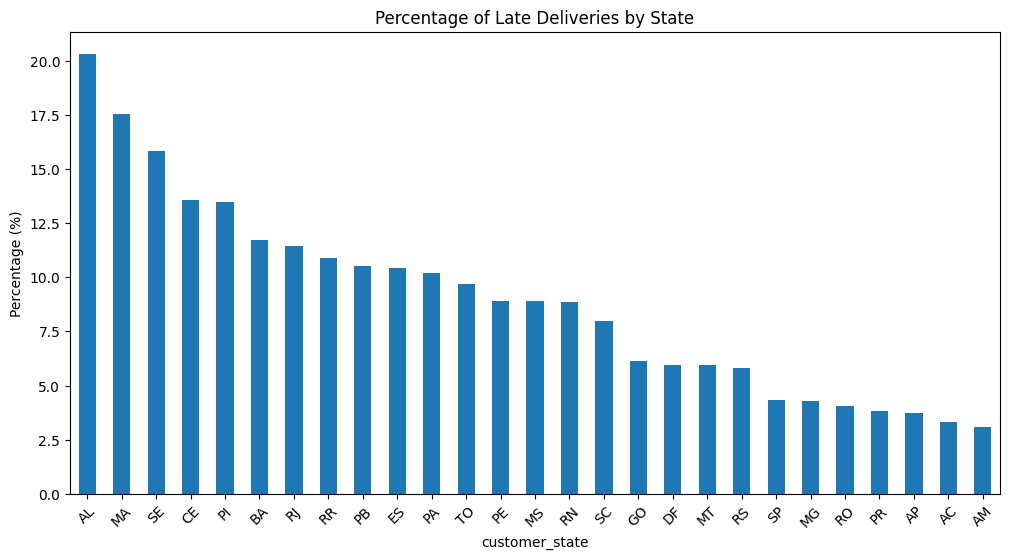

In [14]:
plt.figure(figsize=(12,6))
late_percentage.plot(kind='bar')
plt.title("Percentage of Late Deliveries by State")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45)
plt.show()

States like AL and MA have the highest percentage of late deliveries, suggesting regional logistics inefficiencies.

# Sentiment Analysis (Story 4)

Average review by delivery status

In [15]:
review_by_status = df.groupby('delivery_status')['review_score'].mean()
print(review_by_status)

delivery_status
Late          2.942577
On Time       4.207410
Super Late    1.736842
Name: review_score, dtype: float64


Late deliveries significantly reduce review scores from ~4.2 (on time) to ~2.9 (late), confirming a strong negative impact.

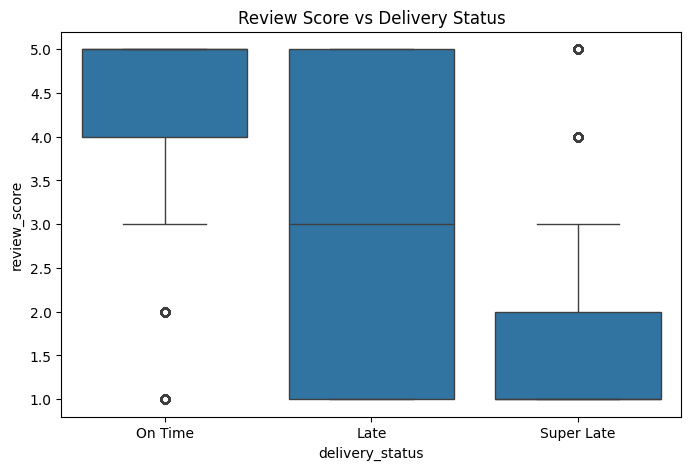

In [16]:
plt.figure(figsize=(8,5))
order = ["On Time", "Late", "Super Late"]
sns.boxplot(x='delivery_status', y='review_score', data=df, order=order)
plt.title("Review Score vs Delivery Status")
plt.show()

The analysis shows a strong relationship between delivery delays and customer satisfaction.
Orders delivered on time consistently receive high review scores (mostly 4–5).
Late deliveries result in more varied ratings, with a noticeable drop in average satisfaction.

However, “Super Late” deliveries (more than 5 days delay) lead to predominantly low ratings (1–2), indicating a severe negative impact on customer experience.

This confirms that inaccurate delivery estimates and delays are a key driver of negative customer reviews.

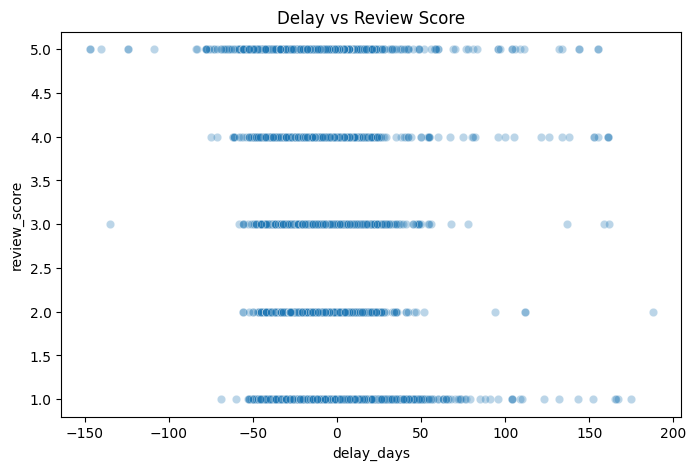

In [17]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='delay_days', y='review_score', data=df, alpha=0.3)
plt.title("Delay vs Review Score")
plt.show()

The scatter plot reveals a clear negative relationship between delivery delay and customer satisfaction. Orders delivered early (negative delay) consistently receive high review scores (4–5), while delayed orders show a wider spread of ratings, with a noticeable increase in low scores (1–2) as delays grow.

In cases of extreme delays, customer satisfaction drops significantly, with most reviews being 1-star. Although some outliers exist, the overall trend strongly confirms that delivery delays are a major driver of negative customer feedback.

# Monthly Analysis

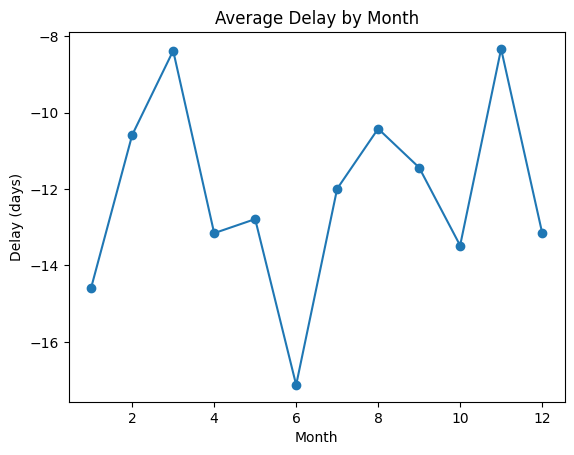

In [18]:
df['month'] = df['order_purchase_timestamp'].dt.month

monthly_delay = df.groupby('month')['delay_days'].mean()

monthly_delay.plot(marker='o')
plt.title("Average Delay by Month")
plt.xlabel("Month")
plt.ylabel("Delay (days)")
plt.show()

While the average delivery delay is negative across all months, indicating early deliveries, this metric masks the presence of late deliveries. The variation in average delay suggests operational differences across months, but it does not fully capture customer experience, as a notable percentage of orders are still delivered late in certain periods.

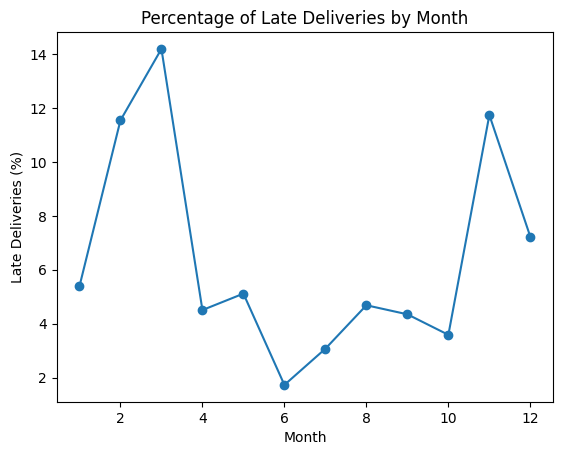

In [19]:
monthly_late_pct = (df['delay_days'] > 0).groupby(df['month']).mean() * 100

monthly_late_pct.plot(marker='o')
plt.title("Percentage of Late Deliveries by Month")
plt.xlabel("Month")
plt.ylabel("Late Deliveries (%)")
plt.show()

The percentage of late deliveries varies significantly across months, revealing clear seasonal patterns. Months such as March and November exhibit the highest delay rates, exceeding 10%, while mid-year months show much lower rates.

This suggests that logistical performance is affected by seasonal demand fluctuations or operational constraints. Despite generally early average delivery times, these peaks in late deliveries indicate that a considerable portion of customers still experience delays during specific periods.

# Translation Check

In [20]:
df[['product_category_name', 'product_category_name_english']].head()

,product_category_name,product_category_name_english
0,utilidades_domesticas,housewares
1,perfumaria,perfumery
2,automotivo,auto
3,pet_shop,pet_shop
4,papelaria,stationery


## Candidate’s Choice
Product category delays

In [21]:
category_delay = df.groupby('product_category_name_english')['delay_days'].mean().sort_values(ascending=False)

print(category_delay.head(10))

product_category_name_english
arts_and_craftmanship                -6.791667
furniture_mattress_and_upholstery    -7.162162
home_comfort_2                       -7.925926
home_confort                         -9.858140
food                                 -9.864476
audio                               -10.091922
fashion_underwear_beach             -10.952381
electronics                         -11.154187
books_imported                      -11.192982
cine_photo                          -11.211268
Name: delay_days, dtype: float64


Certain product categories show higher delays, indicating possible handling or shipping complexity.

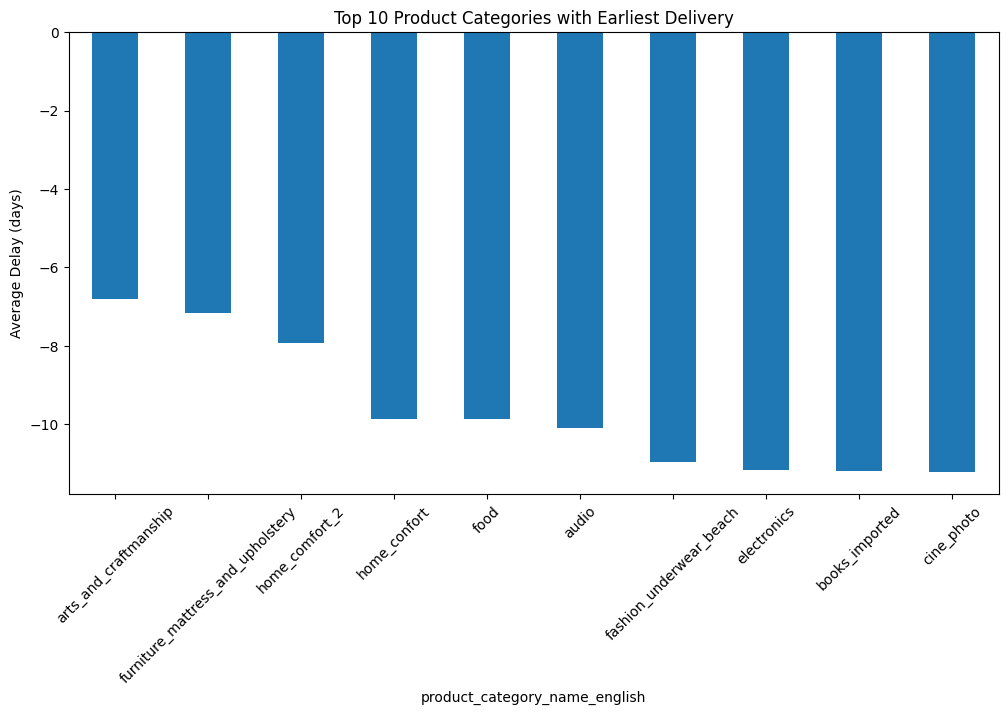

,delay_days
product_category_name_english,
home_appliances_2,21.928571
food_drink,18.454545
music,18.000000
christmas_supplies,15.555556
furniture_mattress_and_upholstery,15.200000
signaling_and_security,15.142857
home_comfort_2,14.500000
air_conditioning,14.200000
drinks,14.125000


In [22]:
plt.figure(figsize=(12,6))
category_delay.head(10).plot(kind='bar')
plt.title("Top 10 Product Categories with Earliest Delivery")
plt.ylabel("Average Delay (days)")
plt.xticks(rotation=45)
plt.show()

late_df = df[df['delay_days'] > 0]

category_delay = late_df.groupby('product_category_name_english')['delay_days'].mean().sort_values(ascending=False)

category_delay.head(10)

The analysis reveals that while many product categories are delivered earlier than estimated on average, there are significant differences across categories. Some categories, such as construction and technical products, consistently arrive earlier than expected.

However, when focusing on delayed deliveries, certain categories such as home appliances and food-related products show substantially higher delay times, exceeding 20 days in some cases.

This suggests that delivery performance is uneven across product categories, and certain types of products may require more careful logistical planning due to their complexity or handling requirements.

# Export final dataset

In [23]:
df.to_csv("final_dataset.csv", index=False)